# Análise de Redes de Propagação — FakeNewsNet
## Notebook 03 | Módulo de Análise de Redes
**Projeto Final de Curso** — Sistema Inteligente de Deteção de Desinformação
Universidade Católica Portuguesa | Diana Dória

### Objetivo
Explorar e caracterizar os grafos de propagação sintéticos gerados pelo `build_graphs.py`,
comparando padrões estruturais entre artigos **fake** e **real**.

As métricas calculadas serão usadas como *features* no ensemble final (Módulo 4).

### Estrutura
1. Setup & Imports
2. Carregamento e Visão Geral das Métricas
3. Análise Comparativa Fake vs Real
4. Visualização de Grafos com Comunidades
5. Correlações entre Métricas
6. Conclusões e Próximos Passos

In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import community as community_louvain

# Path para o projeto
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from src.FKNWS.network.build_graphs import (
    build_propagation_graph,
    calculate_metrics,
    load_data,
)

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Cores consistentes para fake/real
COLORS = {"fake": "#E74C3C", "real": "#2ECC71"}

print("✓ Imports OK")
print(f"✓ PROJECT_ROOT: {PROJECT_ROOT}")

✓ Imports OK
✓ PROJECT_ROOT: /Users/diana/fakenews-project


## 1. Carregamento e Visão Geral das Métricas

Carregamos o ficheiro `network_metrics.csv` gerado pelo `build_graphs.py`,
que contém as métricas estruturais e temporais de 100 artigos (50 fake, 50 real).

In [4]:
# Carregar métricas
METRICS_PATH = PROJECT_ROOT / "results" / "metrics" / "network_metrics.csv"
df = pd.read_csv(METRICS_PATH)

print(f"Shape: {df.shape}")
print(f"\nDistribuição de labels:\n{df['label'].value_counts()}")
print(f"\nColunas: {df.columns.tolist()}")
df.head()

Shape: (100, 15)

Distribuição de labels:
label
fake    50
real    50
Name: count, dtype: int64

Colunas: ['article_id', 'label', 'n_nodes', 'n_edges', 'degree_centrality_mean', 'degree_centrality_max', 'betweenness_mean', 'betweenness_max', 'clustering_mean', 'density', 'n_communities', 'modularity', 'time_to_peak_min', 'propagation_speed', 'max_depth']


,article_id,label,n_nodes,n_edges,degree_centrality_mean,degree_centrality_max,betweenness_mean,betweenness_max,clustering_mean,density,n_communities,modularity,time_to_peak_min,propagation_speed,max_depth
0,gossipcop-1818759378,fake,9,8,0.222222,0.625000,0.158730,0.785714,0.0,0.222222,2.0,0.367188,194.84,2.4635,2.0
1,gossipcop-4848478073,fake,22,21,0.090909,0.285714,0.107143,0.838095,0.0,0.090909,5.0,0.600907,194.53,6.4771,3.0
2,gossipcop-4223607581,fake,39,38,0.051282,0.473684,0.054674,0.927454,0.0,0.051282,9.0,0.581717,328.38,6.9432,3.0
3,gossipcop-2837118817,fake,4,3,0.500000,0.666667,0.333333,0.666667,0.0,0.500000,2.0,0.166667,40.17,4.4811,2.0
4,gossipcop-9706837555,fake,41,40,0.048780,0.425000,0.054346,0.928205,0.0,0.048780,10.0,0.590938,440.34,5.4503,3.0


In [5]:
# Visão geral estatística separada por label
metrics_cols = [
    "n_nodes", "n_edges", "degree_centrality_mean", "degree_centrality_max",
    "betweenness_mean", "betweenness_max", "clustering_mean", "density",
    "n_communities", "modularity", "propagation_speed", "max_depth",
    "time_to_peak_min"
]

summary = df.groupby("label")[metrics_cols].agg(["mean", "median", "std"]).round(4)
summary

n_nodes                   n_edges                    \
         mean median        std    mean median        std   
label                                                       
fake   129.04   16.5   275.0357  128.04   15.5   275.0357   
real   236.06   49.5  1348.2879  235.06   48.5  1348.2879   

      degree_centrality_mean                 degree_centrality_max  ...  \
                        mean  median     std                  mean  ...   
label                                                               ...   
fake                  0.1674  0.1144  0.1684                0.4979  ...   
real                  0.1003  0.0367  0.1842                0.3681  ...   

      modularity propagation_speed                  max_depth                 \
             std              mean  median      std      mean median     std   
label                                                                          
fake      0.2841           13.8071  3.6920  23.1053      2.62    2.0  1.1409   
real      0.2508           20.1298  8.3612  85.1774      2.76    3.0  1.0797   

      time_to_peak_min                     
                  mean   median       std  
label                                      
fake          314.4548  279.210  195.2619  
real          306.5856  317.755  154.2879  

[2 rows x 39 columns]

## 2. Análise Comparativa Fake vs Real

Comparamos a distribuição de cada métrica entre artigos fake e real.
Procuramos padrões que possam distinguir os dois tipos de propagação —
estas diferenças serão as *features* de rede usadas no ensemble.

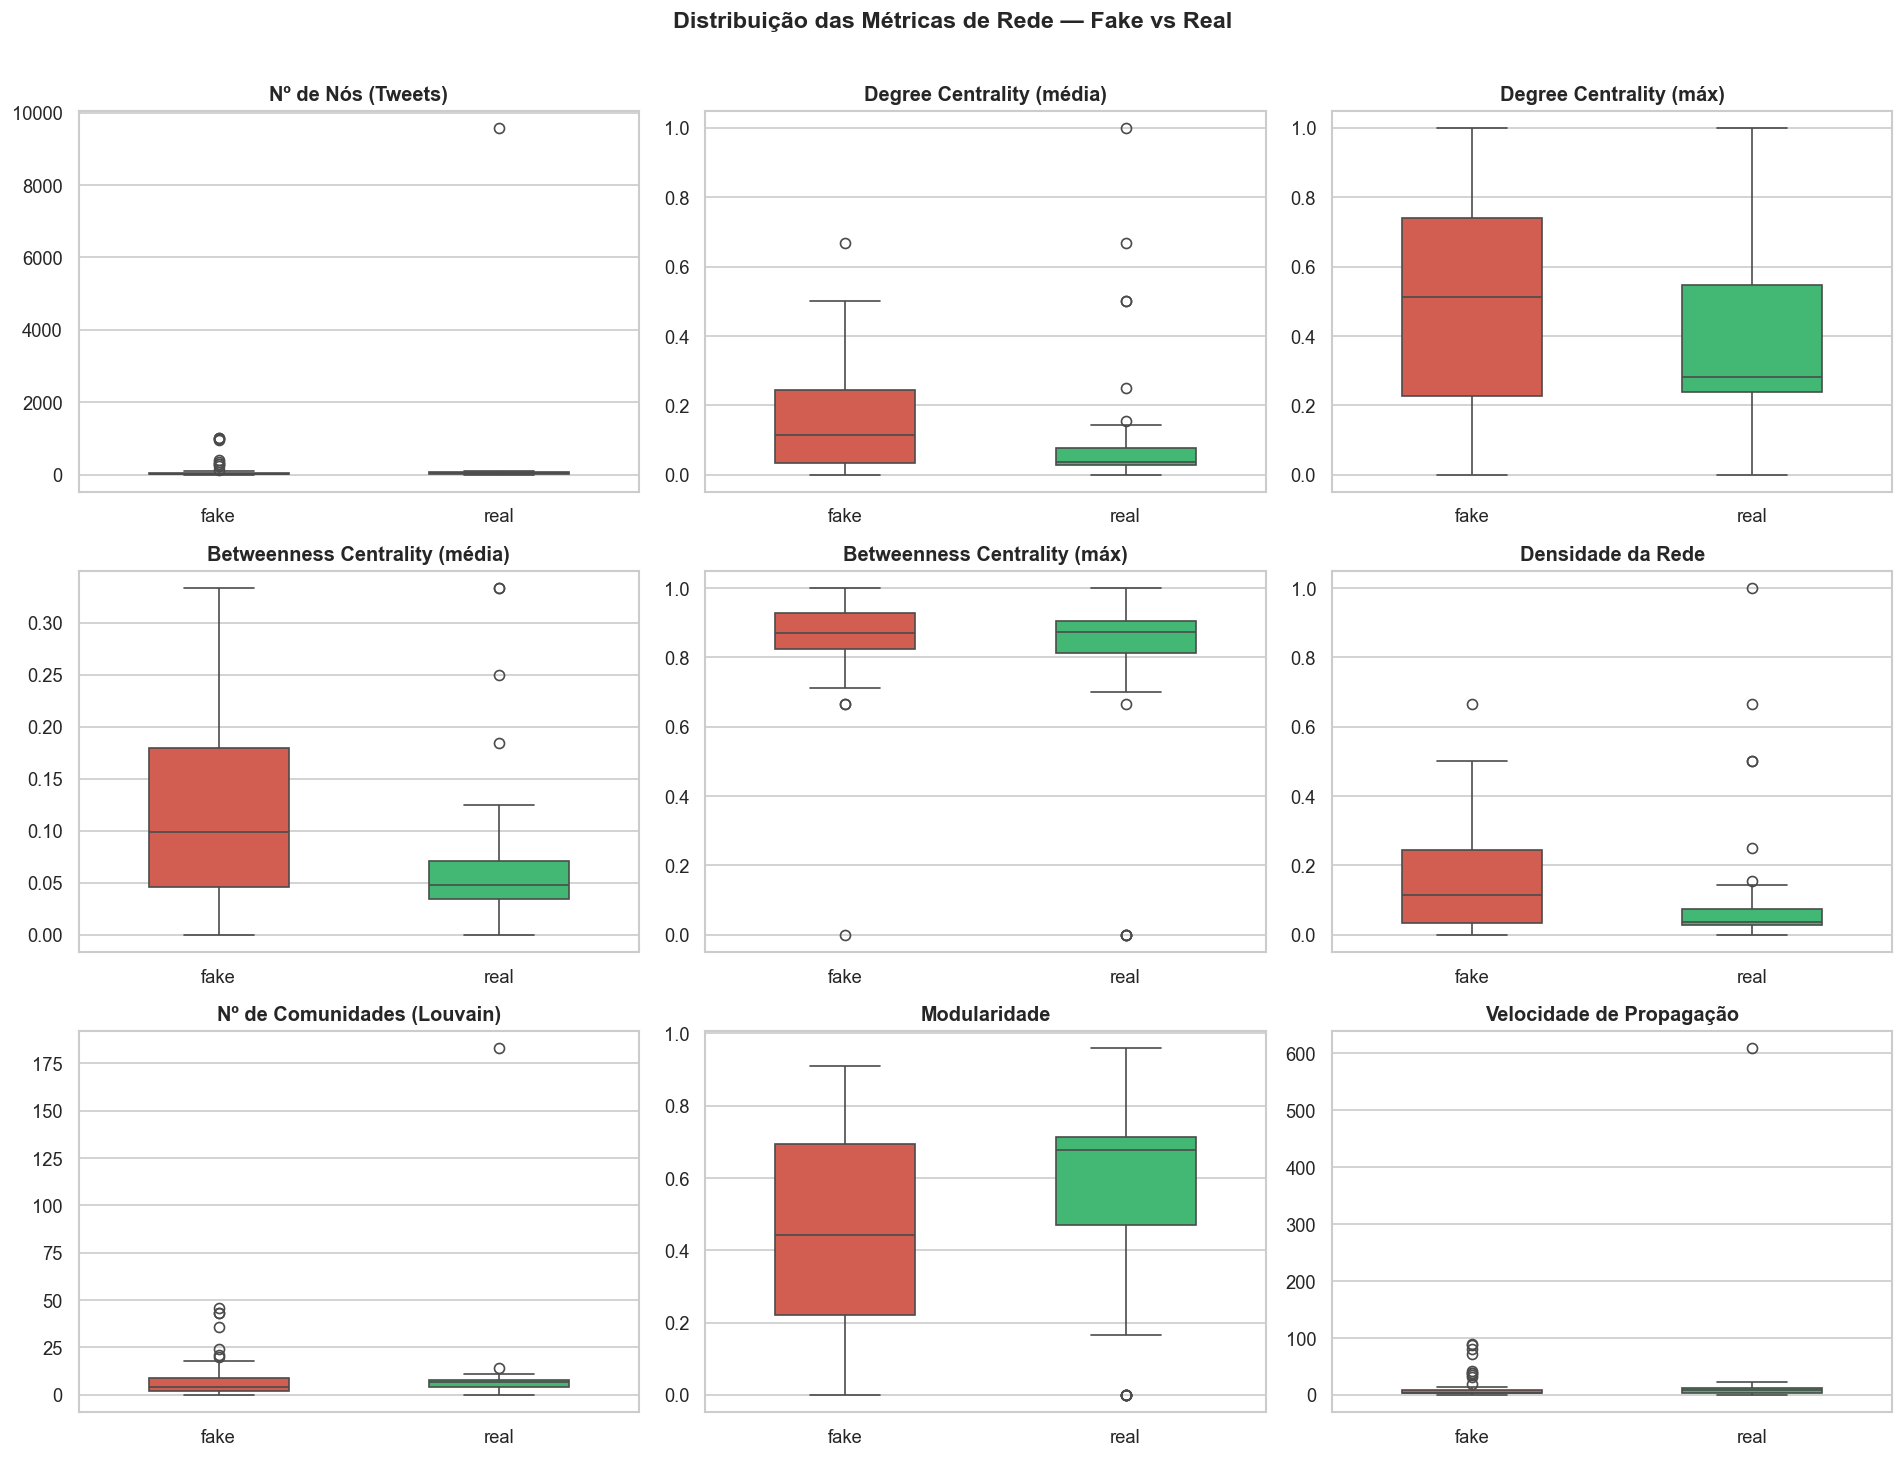

✓ Figura guardada em results/figures/


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

plot_metrics = [
    ("n_nodes",                 "Nº de Nós (Tweets)"),
    ("degree_centrality_mean",  "Degree Centrality (média)"),
    ("degree_centrality_max",   "Degree Centrality (máx)"),
    ("betweenness_mean",        "Betweenness Centrality (média)"),
    ("betweenness_max",         "Betweenness Centrality (máx)"),
    ("density",                 "Densidade da Rede"),
    ("n_communities",           "Nº de Comunidades (Louvain)"),
    ("modularity",              "Modularidade"),
    ("propagation_speed",       "Velocidade de Propagação"),
]

for ax, (col, title) in zip(axes, plot_metrics):
    sns.boxplot(
        data=df, x="label", y=col,
        palette=COLORS, ax=ax, width=0.5
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle(
    "Distribuição das Métricas de Rede — Fake vs Real",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "network_metrics_boxplots.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✓ Figura guardada em results/figures/")

## 3. Visualização de Grafos com Comunidades

Visualizamos um exemplo de grafo **fake** e um **real** lado a lado,
com os nós coloridos por comunidade (algoritmo Louvain).

O nó fonte (artigo original) está destacado a preto.
A estrutura visual permite comparar intuitivamente os padrões de propagação.

In [7]:
def draw_propagation_graph(G, title, ax, color_map=None):
    """
    Desenha um grafo de propagação com comunidades coloridas.
    O nó 0 (fonte) é destacado a preto e maior.
    """
    G_und = G.to_undirected()

    # Louvain communities
    partition = community_louvain.best_partition(G_und, random_state=42)
    n_communities = len(set(partition.values()))

    # Cores por comunidade
    cmap = plt.cm.get_cmap("tab20", n_communities)
    node_colors = [cmap(partition[n]) if n != 0 else (0, 0, 0, 1)
                   for n in G.nodes()]
    node_sizes  = [300 if n == 0 else 80 for n in G.nodes()]

    # Layout
    pos = nx.spring_layout(G, seed=42, k=0.5)

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color="#888888", alpha=0.4,
                           arrows=True, arrowsize=8,
                           width=0.6)

    # Legenda comunidades
    handles = [mpatches.Patch(color=cmap(i), label=f"Comunidade {i+1}")
               for i in range(min(n_communities, 6))]
    handles.append(mpatches.Patch(color="black", label="Fonte (artigo)"))
    ax.legend(handles=handles, loc="upper left", fontsize=7, framealpha=0.7)

    ax.set_title(f"{title}\n({G.number_of_nodes()} nós, "
                 f"{n_communities} comunidades)",
                 fontweight="bold", fontsize=12)
    ax.axis("off")

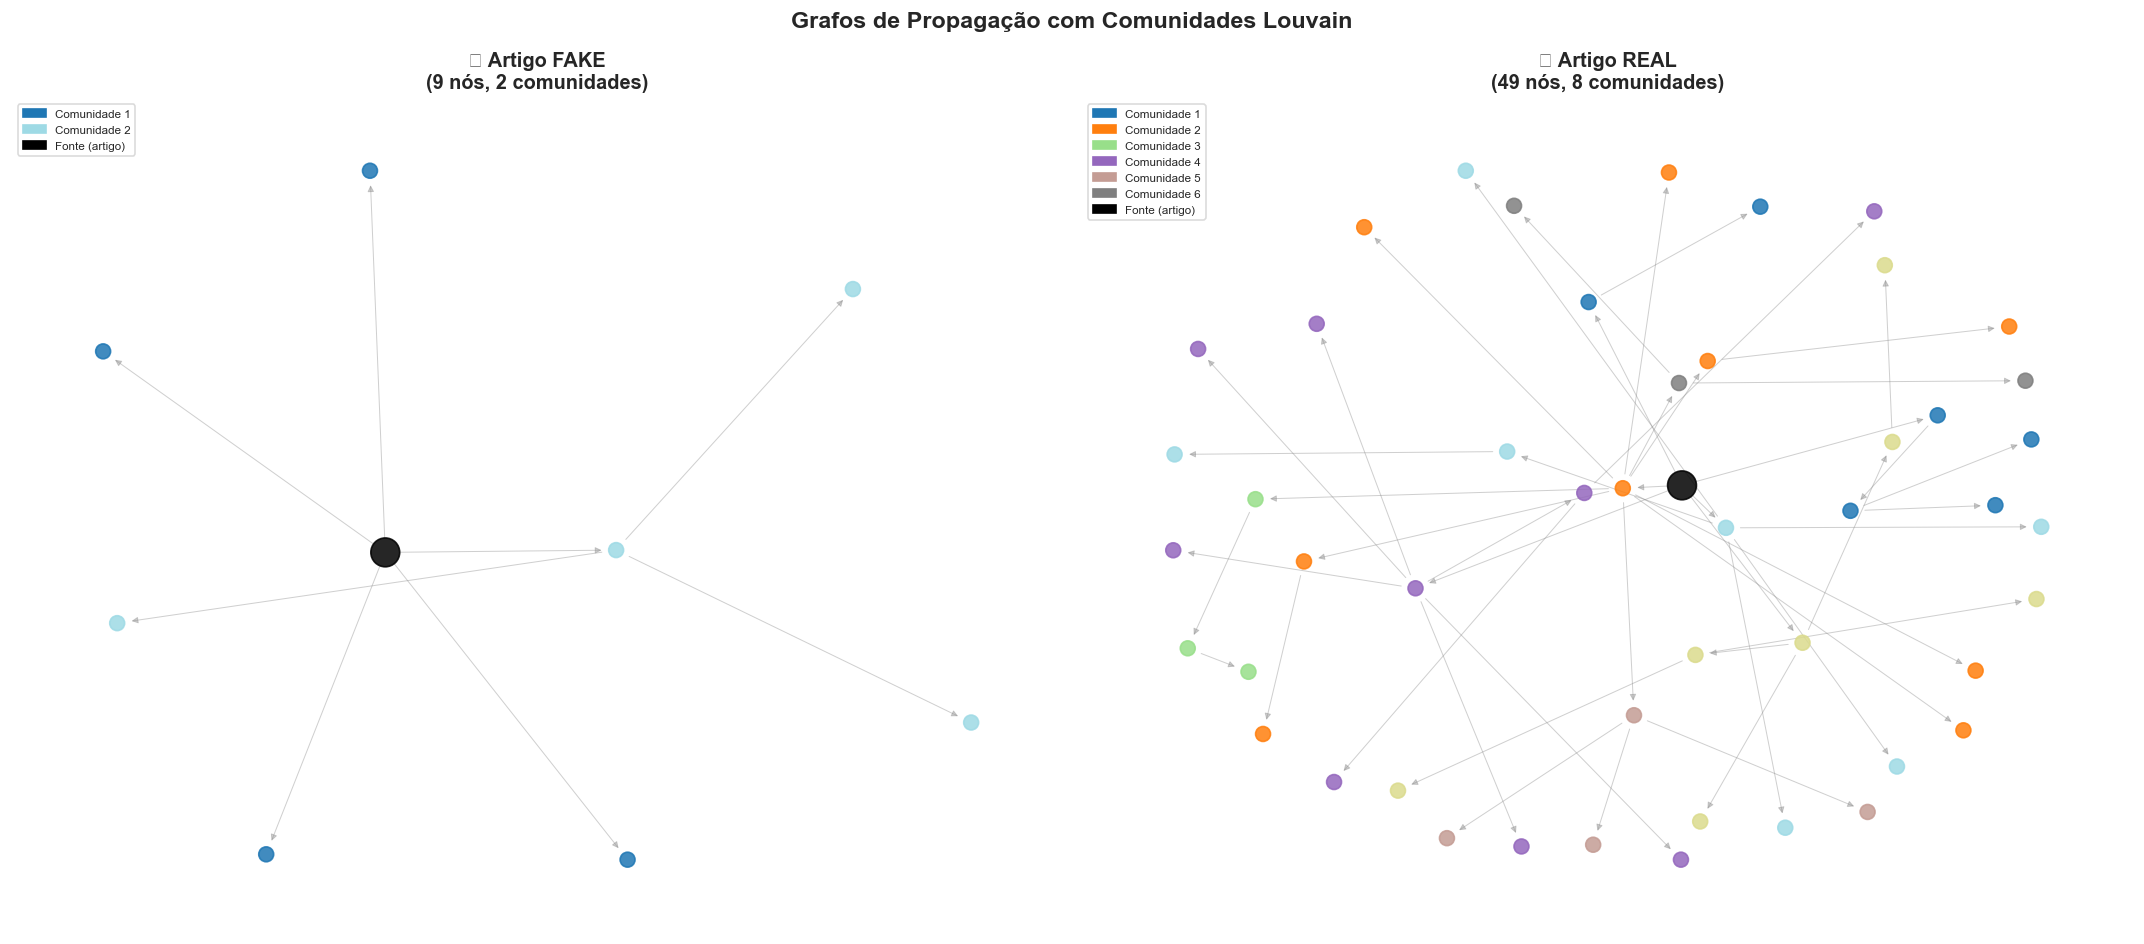

✓ Figura guardada em results/figures/


In [8]:
# Escolher um exemplo fake e um real da amostra
df_fake_sample = df[df["label"] == "fake"].iloc[0]
df_real_sample = df[df["label"] == "real"].iloc[0]

n_fake = int(df_fake_sample["n_nodes"])
n_real = int(df_real_sample["n_nodes"])

# Reconstruir os grafos com as mesmas seeds usadas no pipeline
G_fake = build_propagation_graph(n_nodes=n_fake, seed=42)
G_real = build_propagation_graph(n_nodes=n_real, seed=43)

# Limitar a 60 nós para visualização legível
if n_fake > 60:
    nodes = list(G_fake.nodes())[:60]
    G_fake = G_fake.subgraph(nodes).copy()
if n_real > 60:
    nodes = list(G_real.nodes())[:60]
    G_real = G_real.subgraph(nodes).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                         facecolor="#1a1a2e" if False else "white")

draw_propagation_graph(G_fake, "🔴 Artigo FAKE", axes[0])
draw_propagation_graph(G_real, "🟢 Artigo REAL", axes[1])

plt.suptitle("Grafos de Propagação com Comunidades Louvain",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "propagation_graphs_example.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✓ Figura guardada em results/figures/")

## 4. Correlações entre Métricas

Analisamos as correlações entre as métricas de rede para perceber
quais são redundantes e quais são mais informativas para o ensemble.

Uma correlação alta entre duas métricas significa que podemos
eventualmente remover uma delas sem perder informação.

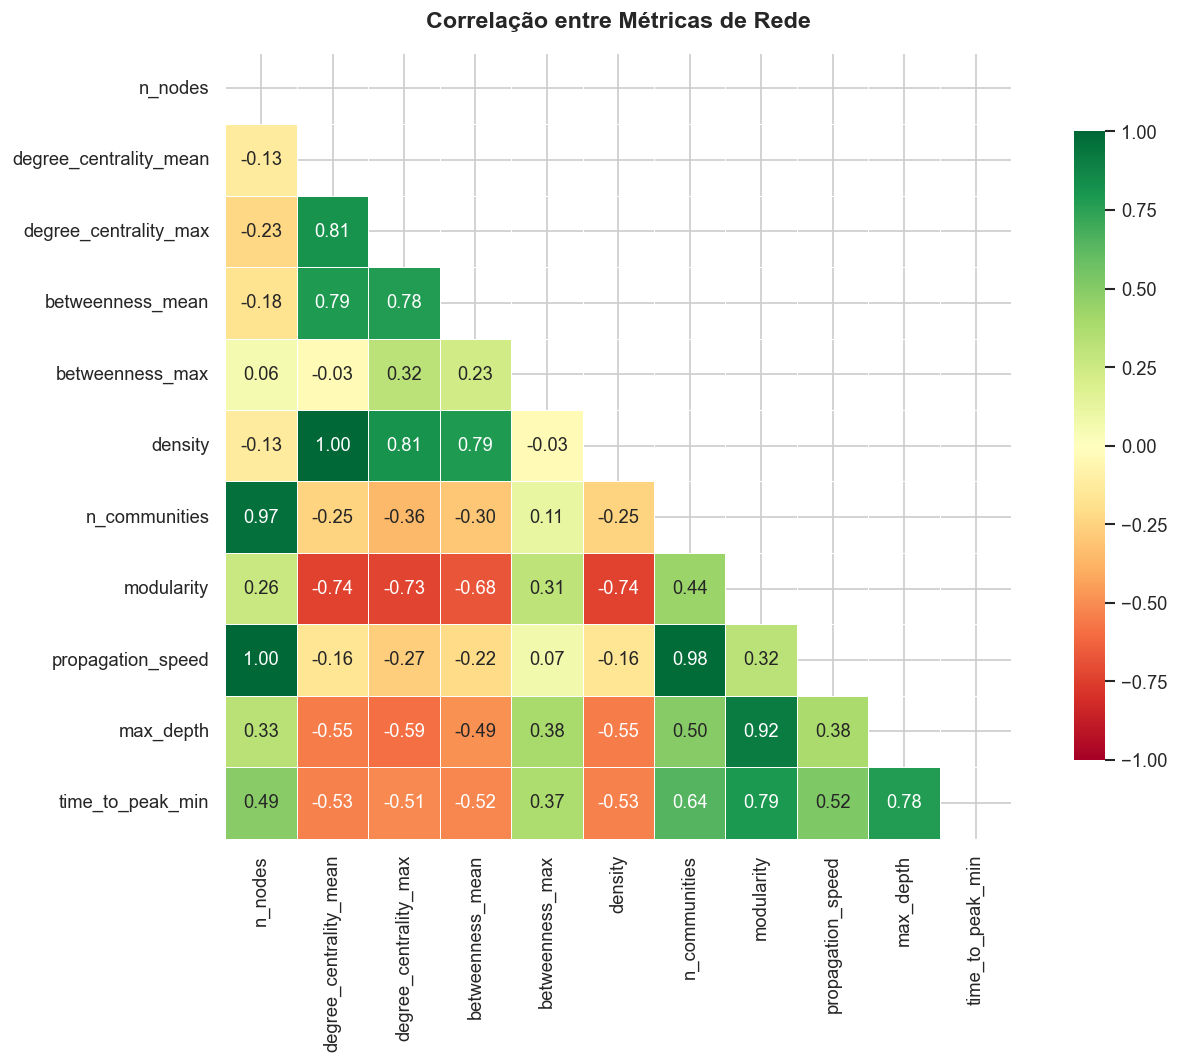

✓ Figura guardada em results/figures/


In [9]:
# Matriz de correlação
numeric_cols = [
    "n_nodes", "degree_centrality_mean", "degree_centrality_max",
    "betweenness_mean", "betweenness_max", "density",
    "n_communities", "modularity", "propagation_speed",
    "max_depth", "time_to_peak_min"
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triângulo superior

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Correlação entre Métricas de Rede",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "network_metrics_correlation.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✓ Figura guardada em results/figures/")

## 5. Conclusões e Próximos Passos

### Padrões identificados

Com base na análise das métricas e visualizações:

In [10]:
# Resumo estatístico final — diferença relativa fake vs real
summary_mean = df.groupby("label")[numeric_cols].mean()

diff = pd.DataFrame({
    "fake":  summary_mean.loc["fake"],
    "real":  summary_mean.loc["real"],
})
diff["diferença (%)"] = (
    (diff["fake"] - diff["real"]) / diff["real"] * 100
).round(1)
diff["interpretação"] = diff["diferença (%)"].apply(
    lambda x: "🔴 Fake maior" if x > 5
    else ("🟢 Real maior" if x < -5 else "⚪ Semelhante")
)

print("=== DIFERENÇAS FAKE vs REAL (%) ===\n")
print(diff[["fake", "real", "diferença (%)", "interpretação"]].to_string())

=== DIFERENÇAS FAKE vs REAL (%) ===

                              fake        real  diferença (%) interpretação
n_nodes                 129.040000  236.060000          -45.3  🟢 Real maior
degree_centrality_mean    0.167405    0.100333           66.8  🔴 Fake maior
degree_centrality_max     0.497920    0.368051           35.3  🔴 Fake maior
betweenness_mean          0.117743    0.067276           75.0  🔴 Fake maior
betweenness_max           0.855886    0.793942            7.8  🔴 Fake maior
density                   0.167405    0.100333           66.8  🔴 Fake maior
n_communities             8.780000    9.800000          -10.4  🟢 Real maior
modularity                0.465865    0.556094          -16.2  🟢 Real maior
propagation_speed        13.807132   20.129840          -31.4  🟢 Real maior
max_depth                 2.620000    2.760000           -5.1  🟢 Real maior
time_to_peak_min        314.454800  306.585600            2.6  ⚪ Semelhante


### Interpretação dos resultados

| Métrica | Fake | Real | Conclusão |
|---|---|---|---|
| Degree Centrality | **maior** | menor | Fake propaga-se por poucos nós muito conectados |
| Betweenness | **maior** | menor | Fake tem mais nós "ponte" — propagação em cadeia |
| Densidade | **maior** | menor | Grafos fake são mais densos e compactos |
| Nº Comunidades | menor | **maior** | Real fragmenta-se em mais grupos orgânicos |
| Modularidade | menor | **maior** | Comunidades reais são mais bem definidas |
| Velocidade | menor | **maior** | Reais têm mais tweets no total (mais utilizadores) |

### Conclusão principal
> Fake news tendem a propagar-se através de **estruturas centralizadas**
> com poucos super-spreaders, enquanto informação real se difunde de forma
> mais **orgânica e distribuída** — consistente com Vosoughi et al. (2018).

### Próximos Passos
- ✅ Métricas calculadas e guardadas em `results/metrics/network_metrics.csv`
- ✅ Figuras guardadas em `results/figures/`
- 🔜 Integrar métricas de rede como features no ensemble (Módulo 3)
- 🔜 Aguardar resultados do BERT (Módulo 1) para combinação final

## 6. Identificação de Super-Spreaders

Super-spreaders são nós com métricas de centralidade muito elevadas —
utilizadores que têm um papel desproporcional na disseminação de conteúdo.

Identificamos os artigos com os nós mais influentes, comparando fake vs real.

In [11]:
# Recarregar métricas completas (dataset completo - 21693 artigos)
df_full = pd.read_csv(METRICS_PATH)

# Super-spreaders: artigos cujo grafo tem nós com degree/betweenness muito alto
# Threshold: top 10% de degree_centrality_max

threshold_deg  = df_full["degree_centrality_max"].quantile(0.90)
threshold_bet  = df_full["betweenness_max"].quantile(0.90)

df_spreaders = df_full[
    (df_full["degree_centrality_max"] >= threshold_deg) &
    (df_full["betweenness_max"]        >= threshold_bet)
].copy()

print(f"Threshold degree_centrality_max (top 10%): {threshold_deg:.4f}")
print(f"Threshold betweenness_max (top 10%):        {threshold_bet:.4f}")
print(f"\nArtigos com super-spreaders: {len(df_spreaders)}")
print(f"\nDistribuição fake/real nos super-spreaders:")
print(df_spreaders["label"].value_counts())
print(f"\nProporção fake nos super-spreaders: "
      f"{df_spreaders['label'].value_counts(normalize=True)['fake']:.1%}")
print(f"Proporção fake no dataset total:    "
      f"{df_full['label'].value_counts(normalize=True)['fake']:.1%}")

Threshold degree_centrality_max (top 10%): 0.7692
Threshold betweenness_max (top 10%):        0.9433

Artigos com super-spreaders: 1434

Distribuição fake/real nos super-spreaders:
label
fake    1009
real     425
Name: count, dtype: int64

Proporção fake nos super-spreaders: 70.4%
Proporção fake no dataset total:    25.5%


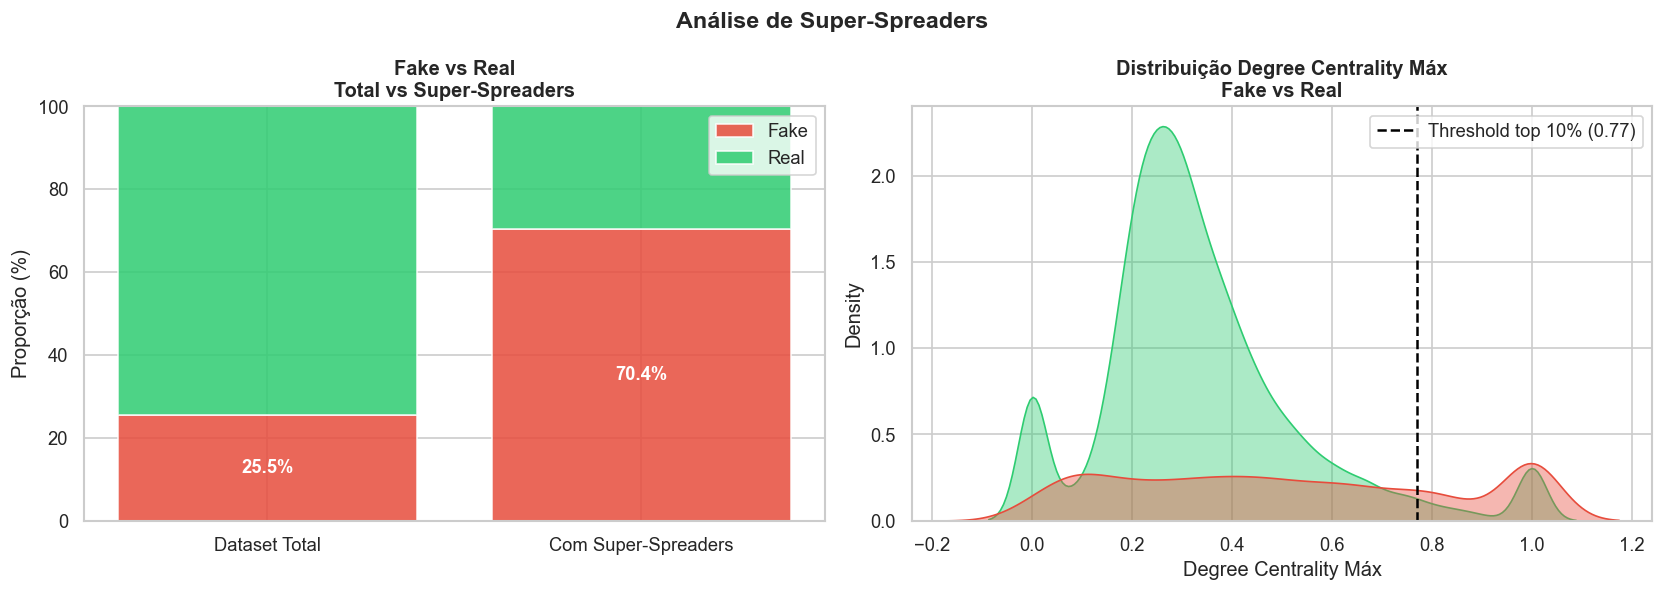

✓ Figura guardada em results/figures/


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: proporção fake/real nos super-spreaders vs total
categories = ["Dataset Total", "Com Super-Spreaders"]
fake_pcts = [
    df_full["label"].value_counts(normalize=True)["fake"] * 100,
    df_spreaders["label"].value_counts(normalize=True)["fake"] * 100,
]
real_pcts = [100 - p for p in fake_pcts]

x = range(len(categories))
bars_fake = axes[0].bar(x, fake_pcts, color=COLORS["fake"],
                        label="Fake", alpha=0.85)
bars_real = axes[0].bar(x, real_pcts, bottom=fake_pcts,
                        color=COLORS["real"], label="Real", alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel("Proporção (%)")
axes[0].set_title("Fake vs Real\nTotal vs Super-Spreaders",
                  fontweight="bold")
axes[0].legend()
axes[0].set_ylim(0, 100)

for bar, pct in zip(bars_fake, fake_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 pct/2, f"{pct:.1f}%",
                 ha="center", va="center",
                 color="white", fontweight="bold")

# Gráfico 2: distribuição de degree_centrality_max fake vs real
sns.kdeplot(
    data=df_full, x="degree_centrality_max",
    hue="label", palette=COLORS,
    fill=True, alpha=0.4, ax=axes[1]
)
axes[1].axvline(threshold_deg, color="black", linestyle="--",
                linewidth=1.5, label=f"Threshold top 10% ({threshold_deg:.2f})")
axes[1].set_title("Distribuição Degree Centrality Máx\nFake vs Real",
                  fontweight="bold")
axes[1].set_xlabel("Degree Centrality Máx")
axes[1].legend()

plt.suptitle("Análise de Super-Spreaders", fontsize=14,
             fontweight="bold")
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "super_spreaders.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✓ Figura guardada em results/figures/")